# Notebook 01 - Análisis exploratorio y preprocesamiento

En este notebook realizamos la carga del dataset, su exploración inicial, limpieza, normalización y preparación para los modelos de aprendizaje profundo.

## 1. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import os
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('Librerías importadas correctamente')

Librerías importadas correctamente


## 2. Carga del dataset

El dataset UCI HAR debe estar descomprimido en la carpeta `data/UCI HAR Dataset/`. Contiene mediciones de acelerómetro y giroscopio de smartphones mientras 30 voluntarios realizaban 6 actividades físicas. Los datos están segmentados en ventanas de 2.56 segundos con 50% de superposición (128 lecturas por ventana).

In [2]:
# Ruta al dataset (debe estar descomprimido en data/UCI HAR Dataset/)
HAR_DIR = '../data/UCI HAR Dataset'

print('Ruta del dataset:', HAR_DIR)
print('Existe:', os.path.exists(HAR_DIR))

Ruta del dataset: ../data/UCI HAR Dataset
Existe: True


In [3]:
def cargar_datos_tabulares(data_dir):
    """
    Carga los datos tabulares del dataset UCI HAR.
    El dataset original tiene nombres de características duplicados en features.txt,
    por lo que se les agrega el índice para hacerlos únicos.
    """
    # Cargar nombres de características
    features_path = os.path.join(data_dir, 'features.txt')
    features = pd.read_csv(features_path, sep=' ', header=None, names=['id', 'nombre'])
    nombres_features = features['nombre'].tolist()

    # El dataset tiene nombres duplicados en features.txt
    # Los hacemos únicos agregando el índice a cada nombre
    nombres_unicos = [f'{nombre}_{i}' for i, nombre in enumerate(nombres_features)]

    # Cargar etiquetas de actividades
    labels_path = os.path.join(data_dir, 'activity_labels.txt')
    etiquetas = pd.read_csv(labels_path, sep=' ', header=None, names=['id', 'actividad'])

    # Cargar conjuntos train y test con nombres únicos
    X_train = pd.read_csv(
        os.path.join(data_dir, 'train', 'X_train.txt'),
        sep='\s+', header=None, names=nombres_unicos
    )
    y_train = pd.read_csv(
        os.path.join(data_dir, 'train', 'y_train.txt'),
        sep='\s+', header=None, names=['actividad']
    )
    X_test = pd.read_csv(
        os.path.join(data_dir, 'test', 'X_test.txt'),
        sep='\s+', header=None, names=nombres_unicos
    )
    y_test = pd.read_csv(
        os.path.join(data_dir, 'test', 'y_test.txt'),
        sep='\s+', header=None, names=['actividad']
    )

    return X_train, y_train, X_test, y_test, etiquetas


X_train, y_train, X_test, y_test, etiquetas = cargar_datos_tabulares(HAR_DIR)

print('Tamaño del conjunto de entrenamiento:', X_train.shape)
print('Tamaño del conjunto de prueba:', X_test.shape)
print('\nActividades:')
print(etiquetas)

Tamaño del conjunto de entrenamiento: (7352, 561)
Tamaño del conjunto de prueba: (2947, 561)

Actividades:
   id           actividad
0   1             WALKING
1   2    WALKING_UPSTAIRS
2   3  WALKING_DOWNSTAIRS
3   4             SITTING
4   5            STANDING
5   6              LAYING


El dataset tiene 561 características estadísticas extraídas de las señales. El dataset original contiene nombres de características duplicados en `features.txt` (como las bandas de energía), por eso les agregamos el índice para evitar conflictos al cargar con pandas.

Las 6 actividades son: WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS, SITTING, STANDING, LAYING.

## 3. Análisis exploratorio inicial

In [4]:
mapa_actividades = {
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING'
}

y_train_nombres = y_train['actividad'].map(mapa_actividades)
y_test_nombres = y_test['actividad'].map(mapa_actividades)

print('Distribución de actividades en entrenamiento:')
print(y_train_nombres.value_counts())
print('\nDistribución de actividades en prueba:')
print(y_test_nombres.value_counts())

Distribución de actividades en entrenamiento:
actividad
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64

Distribución de actividades en prueba:
actividad
LAYING                537
STANDING              532
WALKING               496
SITTING               491
WALKING_UPSTAIRS      471
WALKING_DOWNSTAIRS    420
Name: count, dtype: int64


In [5]:
# Vista previa del dataset
print('Primeras 5 filas (primeras 8 columnas):')
X_train.iloc[:5, :8]

Primeras 5 filas (primeras 8 columnas):


,tBodyAcc-mean()-X_0,tBodyAcc-mean()-Y_1,tBodyAcc-mean()-Z_2,tBodyAcc-std()-X_3,tBodyAcc-std()-Y_4,tBodyAcc-std()-Z_5,tBodyAcc-mad()-X_6,tBodyAcc-mad()-Y_7
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672


In [6]:
print('Estadísticas descriptivas (primeras 10 características):')
X_train.iloc[:, :10].describe().round(3)

Estadísticas descriptivas (primeras 10 características):


,tBodyAcc-mean()-X_0,tBodyAcc-mean()-Y_1,tBodyAcc-mean()-Z_2,tBodyAcc-std()-X_3,tBodyAcc-std()-Y_4,tBodyAcc-std()-Z_5,tBodyAcc-mad()-X_6,tBodyAcc-mad()-Y_7,tBodyAcc-mad()-Z_8,tBodyAcc-max()-X_9
count,7352.000,7352.000,7352.000,7352.000,7352.000,7352.000,7352.000,7352.000,7352.000,7352.000
mean,0.274,-0.018,-0.109,-0.605,-0.511,-0.605,-0.631,-0.527,-0.606,-0.469
std,0.070,0.041,0.057,0.449,0.503,0.419,0.424,0.486,0.414,0.545
min,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000,-1.000
25%,0.263,-0.025,-0.121,-0.993,-0.978,-0.980,-0.994,-0.978,-0.980,-0.936
50%,0.277,-0.017,-0.109,-0.946,-0.852,-0.859,-0.951,-0.857,-0.857,-0.882
75%,0.288,-0.011,-0.098,-0.243,-0.034,-0.262,-0.293,-0.067,-0.266,-0.017
max,1.000,1.000,1.000,1.000,0.916,1.000,1.000,0.968,1.000,1.000


Los valores están en su mayoría entre -1 y 1 porque el dataset original ya fue normalizado por sus autores. Aun así, aplicaremos StandardScaler para garantizar una distribución uniforme para todos los modelos.

## 4. Visualización del Balanceo de Clases

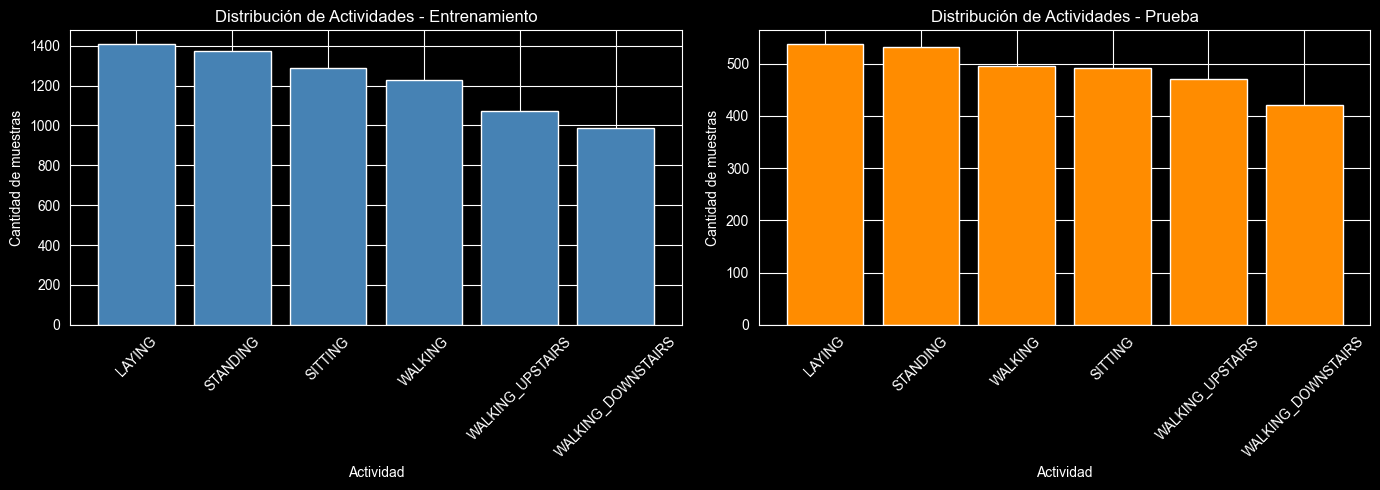

Gráfico guardado.


In [7]:
os.makedirs('../reports', exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

conteo_train = y_train_nombres.value_counts()
axes[0].bar(conteo_train.index, conteo_train.values, color='steelblue')
axes[0].set_title('Distribución de Actividades - Entrenamiento')
axes[0].set_xlabel('Actividad')
axes[0].set_ylabel('Cantidad de muestras')
axes[0].tick_params(axis='x', rotation=45)

conteo_test = y_test_nombres.value_counts()
axes[1].bar(conteo_test.index, conteo_test.values, color='darkorange')
axes[1].set_title('Distribución de Actividades - Prueba')
axes[1].set_xlabel('Actividad')
axes[1].set_ylabel('Cantidad de muestras')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/balanceo_clases.png', dpi=100, bbox_inches='tight')
plt.show()
print('Gráfico guardado.')

El dataset está razonablemente balanceado. No es necesario aplicar técnicas de balanceo como SMOTE o sobremuestreo.

## 5. Análisis de las señales de sensores

Cargamos las señales crudas (datos de series de tiempo) para visualizar cómo lucen por actividad.

In [8]:
def cargar_senales(data_dir, split='train'):
    """Carga las señales crudas de los sensores. Retorna shape (muestras, 128, 9)."""
    signals_dir = os.path.join(data_dir, split, 'Inertial Signals')
    archivos = [
        'body_acc_x', 'body_acc_y', 'body_acc_z',
        'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
        'total_acc_x', 'total_acc_y', 'total_acc_z'
    ]
    senales = []
    for archivo in archivos:
        ruta = os.path.join(signals_dir, f'{archivo}_{split}.txt')
        datos = pd.read_csv(ruta, sep='\s+', header=None).values
        senales.append(datos)
    return np.stack(senales, axis=2)


X_train_seq = cargar_senales(HAR_DIR, 'train')
X_test_seq = cargar_senales(HAR_DIR, 'test')

print('Shape señales entrenamiento:', X_train_seq.shape)
print('Interpretación: (muestras, 128 pasos de tiempo, 9 canales de sensor)')

Shape señales entrenamiento: (7352, 128, 9)
Interpretación: (muestras, 128 pasos de tiempo, 9 canales de sensor)


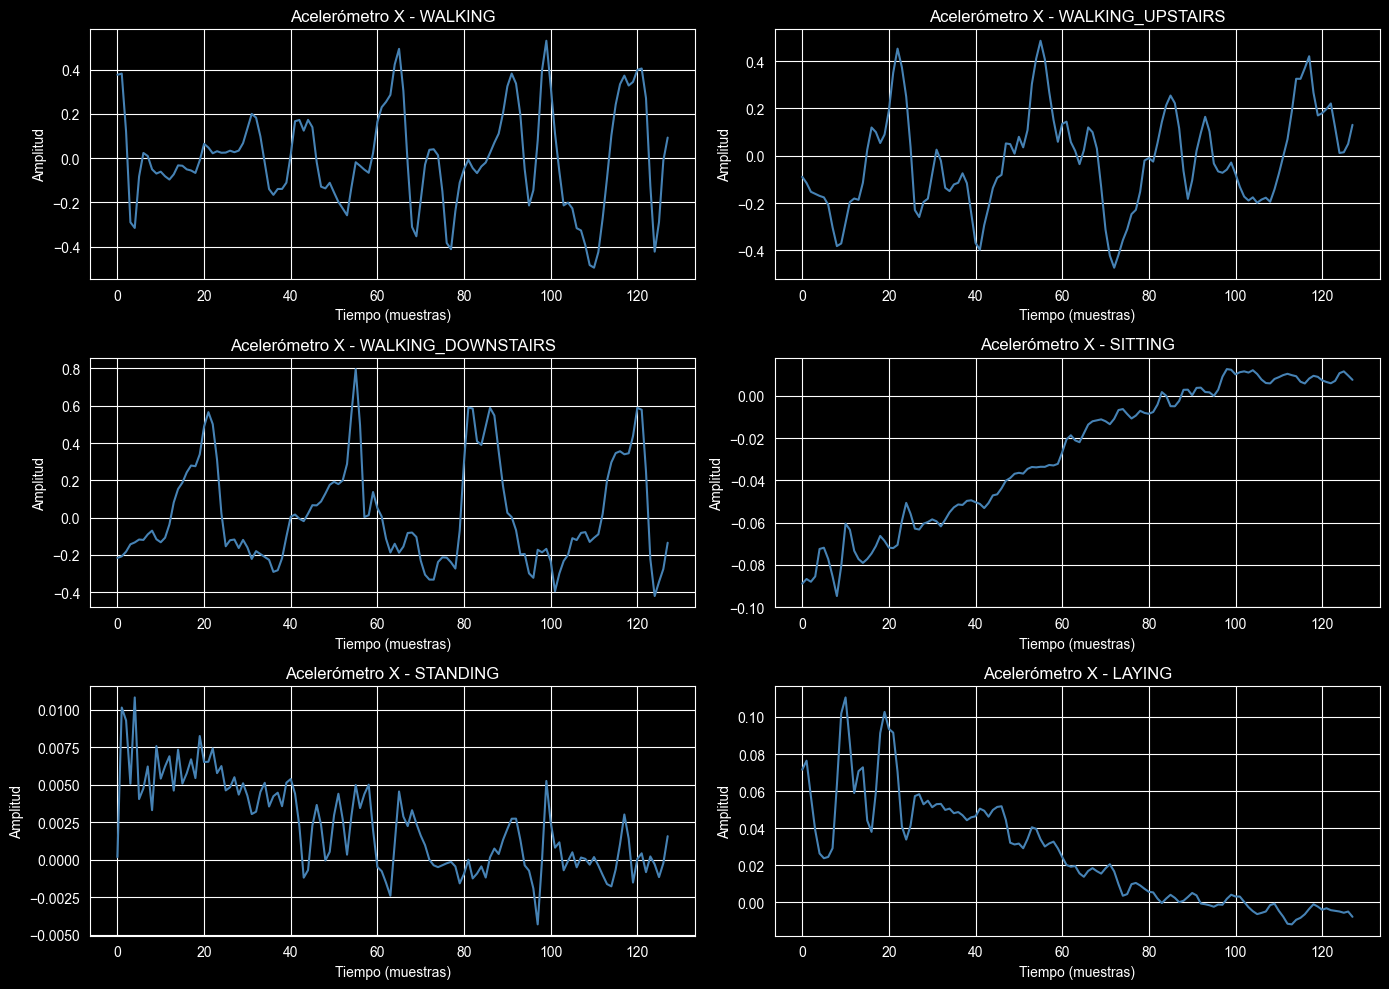

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, clase in enumerate([1, 2, 3, 4, 5, 6]):
    idx = np.where(y_train['actividad'].values == clase)[0][0]
    senal = X_train_seq[idx, :, 0]  # canal: acelerómetro X
    axes[i].plot(senal, color='steelblue')
    axes[i].set_title(f'Acelerómetro X - {mapa_actividades[clase]}')
    axes[i].set_xlabel('Tiempo (muestras)')
    axes[i].set_ylabel('Amplitud')

plt.tight_layout()
plt.savefig('../reports/senales_por_actividad.png', dpi=100, bbox_inches='tight')
plt.show()

Las actividades dinámicas (caminar, subir/bajar escaleras) presentan oscilaciones de mayor amplitud, mientras que las estáticas (sentado, de pie, acostado) muestran señales casi constantes. Esto indica buena separabilidad entre clases.

## 6. Análisis de valores faltantes y duplicados

In [10]:
nulos_train = X_train.isnull().sum().sum()
nulos_test = X_test.isnull().sum().sum()
duplicados_train = X_train.duplicated().sum()
duplicados_test = X_test.duplicated().sum()

print(f'Valores nulos en entrenamiento: {nulos_train}')
print(f'Valores nulos en prueba: {nulos_test}')
print(f'Filas duplicadas en entrenamiento: {duplicados_train}')
print(f'Filas duplicadas en prueba: {duplicados_test}')

Valores nulos en entrenamiento: 0
Valores nulos en prueba: 0
Filas duplicadas en entrenamiento: 0
Filas duplicadas en prueba: 0


El dataset está limpio: sin valores nulos ni filas duplicadas.

## 7. Visualización de correlaciones

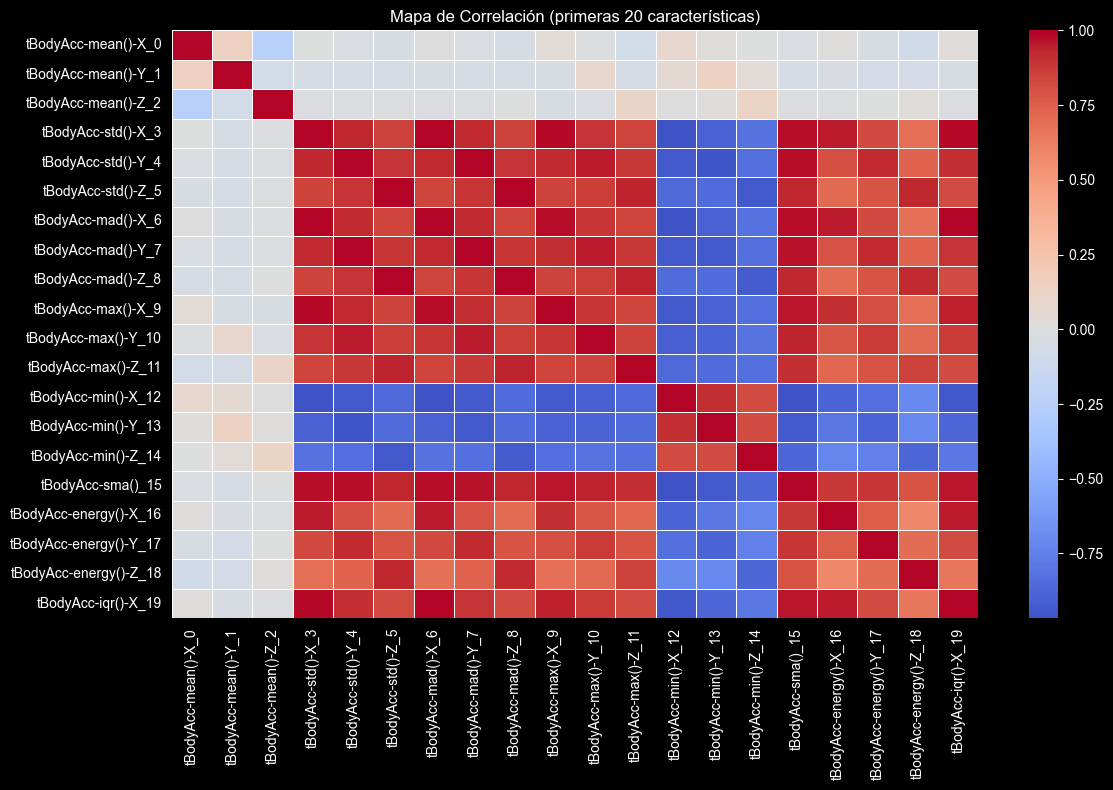

In [11]:
corr_matrix = X_train.iloc[:, :20].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Mapa de Correlación (primeras 20 características)')
plt.tight_layout()
plt.savefig('../reports/correlacion_features.png', dpi=100, bbox_inches='tight')
plt.show()

Algunas características están correlacionadas entre sí, lo cual es normal al extraer múltiples estadísticas de la misma señal. Los modelos de aprendizaje profundo manejan esta redundancia sin requerir reducción de dimensionalidad.

## 8. Normalización

In [12]:
scaler = StandardScaler()

# Ajustar SOLO con datos de entrenamiento, luego transformar ambos conjuntos
X_train_scaled = scaler.fit_transform(X_train.values)
X_test_scaled = scaler.transform(X_test.values)

print('Media después de normalizar (entrenamiento):', X_train_scaled.mean().round(4))
print('Desv. estándar después de normalizar (entrenamiento):', X_train_scaled.std().round(4))

Media después de normalizar (entrenamiento): 0.0
Desv. estándar después de normalizar (entrenamiento): 1.0


## 9. Preparación de etiquetas

In [13]:
from tensorflow.keras.utils import to_categorical

# Convertir etiquetas de 1-6 a 0-5
y_train_int = y_train['actividad'].values - 1
y_test_int = y_test['actividad'].values - 1

# One-hot encoding
y_train_oh = to_categorical(y_train_int, num_classes=6)
y_test_oh = to_categorical(y_test_int, num_classes=6)

print('Shape etiquetas entrenamiento (one-hot):', y_train_oh.shape)
print('Ejemplo de etiqueta one-hot:', y_train_oh[0])
print('Clase correspondiente:', mapa_actividades[y_train_int[0] + 1])

Shape etiquetas entrenamiento (one-hot): (7352, 6)
Ejemplo de etiqueta one-hot: [0. 0. 0. 0. 1. 0.]
Clase correspondiente: STANDING


## 10. División Train / Validation / Test

In [14]:
# División del entrenamiento: 80% train, 20% validación
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train_oh,
    test_size=0.2, random_state=42, stratify=y_train_int
)

y_tr_int, y_val_int = train_test_split(
    y_train_int, test_size=0.2, random_state=42, stratify=y_train_int
)

print('Train:', X_tr.shape)
print('Validation:', X_val.shape)
print('Test:', X_test_scaled.shape)

Train: (5881, 561)
Validation: (1471, 561)
Test: (2947, 561)


## 11. Preparación de secuencias para redes recurrentes

Las redes RNN, LSTM, GRU y Transformer requieren datos en formato 3D: (muestras, pasos_tiempo, características).

In [15]:
# Dividir señales con los mismos índices que los datos tabulares
indices = np.arange(len(X_train_seq))
idx_tr, idx_val = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y_train_int
)

X_tr_seq  = X_train_seq[idx_tr]
X_val_seq = X_train_seq[idx_val]
X_test_seq_final = X_test_seq

y_tr_seq  = y_train_oh[idx_tr]
y_val_seq = y_train_oh[idx_val]
y_test_seq = y_test_oh

y_tr_seq_int  = y_train_int[idx_tr]
y_val_seq_int = y_train_int[idx_val]

print('Secuencias entrenamiento:', X_tr_seq.shape)
print('Secuencias validación:', X_val_seq.shape)
print('Secuencias prueba:', X_test_seq_final.shape)
print('\nFormato: (muestras, 128 pasos de tiempo, 9 canales)')

Secuencias entrenamiento: (5881, 128, 9)
Secuencias validación: (1471, 128, 9)
Secuencias prueba: (2947, 128, 9)

Formato: (muestras, 128 pasos de tiempo, 9 canales)


## 12. Guardado de datos procesados

In [16]:
processed_dir = '../data/processed'
os.makedirs(processed_dir, exist_ok=True)

# Datos tabulares (para MLP)
np.save(os.path.join(processed_dir, 'X_tr.npy'), X_tr)
np.save(os.path.join(processed_dir, 'X_val.npy'), X_val)
np.save(os.path.join(processed_dir, 'X_test.npy'), X_test_scaled)
np.save(os.path.join(processed_dir, 'y_tr.npy'), y_tr)
np.save(os.path.join(processed_dir, 'y_val.npy'), y_val)
np.save(os.path.join(processed_dir, 'y_test.npy'), y_test_oh)
np.save(os.path.join(processed_dir, 'y_tr_int.npy'), y_tr_int)
np.save(os.path.join(processed_dir, 'y_val_int.npy'), y_val_int)
np.save(os.path.join(processed_dir, 'y_test_int.npy'), y_test_int)

# Datos secuenciales (para CNN, RNN, LSTM, GRU, Transformer)
np.save(os.path.join(processed_dir, 'X_tr_seq.npy'), X_tr_seq)
np.save(os.path.join(processed_dir, 'X_val_seq.npy'), X_val_seq)
np.save(os.path.join(processed_dir, 'X_test_seq.npy'), X_test_seq_final)
np.save(os.path.join(processed_dir, 'y_tr_seq.npy'), y_tr_seq)
np.save(os.path.join(processed_dir, 'y_val_seq.npy'), y_val_seq)
np.save(os.path.join(processed_dir, 'y_test_seq.npy'), y_test_seq)
np.save(os.path.join(processed_dir, 'y_tr_seq_int.npy'), y_tr_seq_int)
np.save(os.path.join(processed_dir, 'y_val_seq_int.npy'), y_val_seq_int)

print('Archivos guardados en:', processed_dir)
print('Total archivos:', len(os.listdir(processed_dir)))

Archivos guardados en: ../data/processed
Total archivos: 17


## Resumen del preprocesamiento

Pasos realizados en este notebook:

1. **Carga del dataset** desde `data/UCI HAR Dataset/`. Los nombres duplicados de características se resuelven agregando el índice a cada nombre.
2. **Exploración inicial**: estructura, estadísticas descriptivas, tipos de datos.
3. **Análisis de balanceo**: las 6 clases están razonablemente balanceadas.
4. **Visualización de señales**: diferencias claras entre actividades dinámicas y estáticas.
5. **Limpieza**: sin valores nulos ni duplicados.
6. **Normalización**: StandardScaler ajustado solo sobre el conjunto de entrenamiento.
7. **Codificación de etiquetas**: one-hot encoding con 6 clases.
8. **División**: 80% entrenamiento, 20% validación (estratificada).
9. **Secuencias**: datos crudos en formato (muestras, 128, 9) para modelos recurrentes.
10. **Guardado**: todos los conjuntos procesados en `data/processed/` listos para los notebooks siguientes.